In [1]:
import numpy as np
import os
import pandas as pd
import sys
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import matplotlib.colors
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
import matplotlib.patches as mpatches
import json

import h5py
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import csv

# bnsi_path = '/scicore/home/nimwegen/degroo0000/Bonsai-data-representation'
bnsi_path = "/scicore/home/nimwegen/morill0000/software/Bonsai-data-representation"
sys.path.append(bnsi_path)
from bonsai_scout.bonsai_scout_helpers import Bonvis_figure, Bonvis_settings, Bonvis_metadata, Annotation_info, get_celltype_colors_new

/scratch/morill0000/slurm-job.5833188/ipykernel_229825/2513375769.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
os.getcwd()

'/scicore/home/nimwegen/morill0000/project-bonsai/analysis/hao_satija-CITEseq/bonsai_hao-symlink-group'

## Path to data

In [8]:
path_to_output = "/scicore/home/nimwegen/degroo0000/Bonsai-data-representation/slurm_runs_pipeline/output/hao_satija_2021-immune_cells_all/hao_satija_floats_addedpromotercounts_improved_sanity/removed_doublets_threshold_014"
save_dir = os.path.join(path_to_output, "figures")
print(save_dir)

bonsai_results_folders = os.path.join(path_to_output, "bonsai")

/scicore/home/nimwegen/degroo0000/Bonsai-data-representation/slurm_runs_pipeline/output/hao_satija_2021-immune_cells_all/hao_satija_floats_addedpromotercounts_improved_sanity/removed_doublets_threshold_014/figures


## Bonsai tree

02-19 11:33:46 h5py._conv __getitem__ Creating converter from 3 to 5


/scicore/home/nimwegen/degroo0000/Bonsai-data-representation/slurm_runs_pipeline/output/hao_satija_2021-immune_cells_all/hao_satija_floats_addedpromotercounts_improved_sanity/removed_doublets_threshold_014/bonsai
read in file: /scicore/home/nimwegen/degroo0000/Bonsai-data-representation/slurm_runs_pipeline/output/hao_satija_2021-immune_cells_all/hao_satija_floats_addedpromotercounts_improved_sanity/removed_doublets_threshold_014/bonsai/bonsai_vis_data.hdf


02-19 11:33:49 root create_figure Creating figure!
02-19 11:33:49 root update_figure geometry=flat, zoom=None, click=None, node_style=Rna_annotations, size_style=None, scale_nodes=None, scale_edges=None, scale_node_edges=None, origin=None, ly_type=ly_dendrogram_ladderized, tweak_inds=4218, multip_angle=None, reset_layout=None, ax_lims=None, zoom_ax_lims=None, renew_mask=False, flipped_node_ids=[], new_flip_id=True


[]


02-19 11:33:49 root create_figure Creating figure!


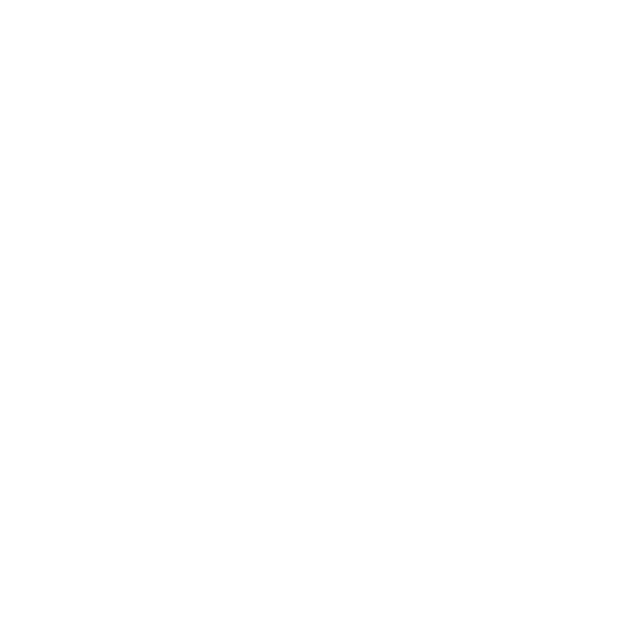

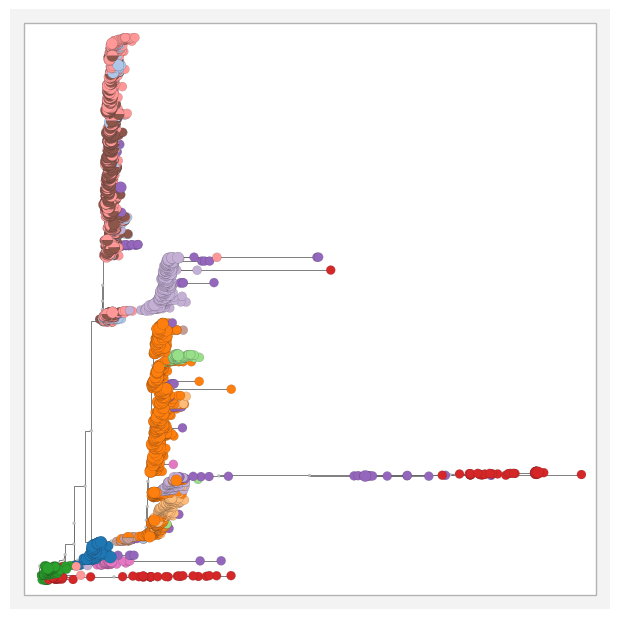

In [9]:
# %%capture  
print(bonsai_results_folders)
data_path = os.path.join(bonsai_results_folders, 'bonsai_vis_data.hdf')
settings_path = os.path.join(bonsai_results_folders, 'bonsai_vis_settings.json')

print("read in file: {}".format(data_path))
bonvis_metadata = Bonvis_metadata(data_path)
bonvis_settings = Bonvis_settings(load_settings_path=settings_path)
bonvis_data_hdf = h5py.File(data_path, 'r')

# Set darker edges
bonvis_settings.edge_style = {"color": [0.4117647058823529, 0.4117647058823529, 0.4117647058823529, 1.0],
                             'linewidth':0.6}


bonvis_fig = Bonvis_figure(bonvis_data_hdf, 
                           bonvis_metadata, 
                           bonvis_data_path=data_path,
                           bonvis_settings=bonvis_settings)
celltype_info = bonvis_fig.bonvis_settings.celltype_info



bonvis_fig.create_figure(figsize=(6, 6))

# Here, we set the desired celltype-annotation for the dataset
node_style = celltype_info.annot_infos['annot_rna_annotations'].label

# Visualize the tree in the ly_dendrogram layout, with the correct celltype-annotation
geometry = 'flat'
ly_type = "ly_dendrogram_ladderized"

bonvis_fig.update_figure(ly_type=ly_type, 
                         geometry=geometry, 
                         node_style=node_style, 
                         tweak_inds=4218, # change root
                         new_flip_id=True
                        )


bonsai_fig_darker_lines = bonvis_fig.create_figure(figsize=(6, 6))
bonsai_fig_darker_lines.savefig("{}/bonsai_dendogram-rna_annot-darker_lines_full-no_doublets.svg".format(save_dir))
bonsai_fig_darker_lines.savefig("{}/bonsai_dendogram-rna_annot-darker_lines_full-no_doublets.png".format(save_dir))